## Importar bibliotecas y leer DF

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score,precision_score, recall_score,f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC,LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import kagglehub
import os


In [ ]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

file_path = os.path.join(path, "creditcard.csv")

df = pd.read_csv(file_path)

Path to dataset files: C:\Users\mar_c\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


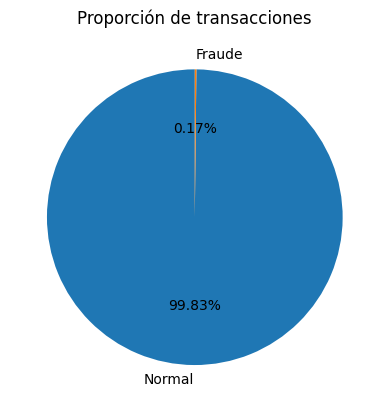

In [5]:

counts = df['Class'].value_counts()

plt.figure()
plt.pie(
    counts.values,
    labels=['Normal', 'Fraude'],
    autopct='%1.2f%%',
    startangle=90
)

plt.title("Proporción de transacciones")
plt.show()

# EDA

In [6]:
##Describe de los datos
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


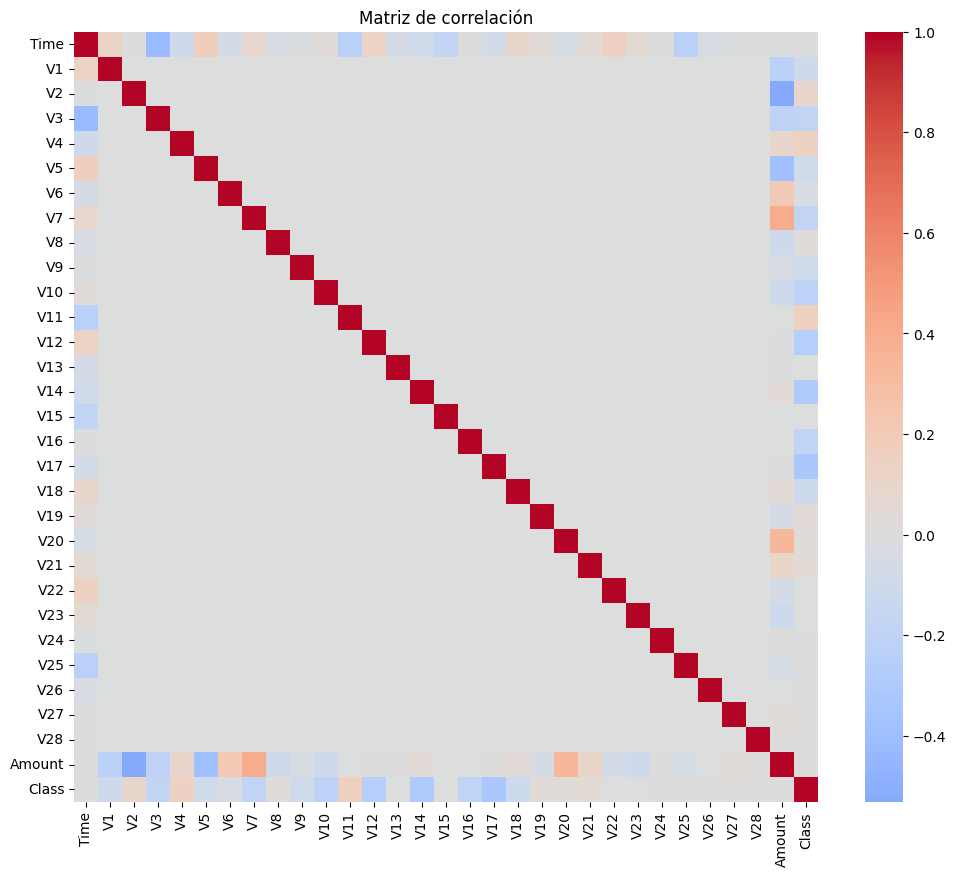

In [7]:
corr = df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Matriz de correlación")
plt.show()

In [8]:
corr_target = df.corr()['Class'].sort_values(ascending=False)
corr_target

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

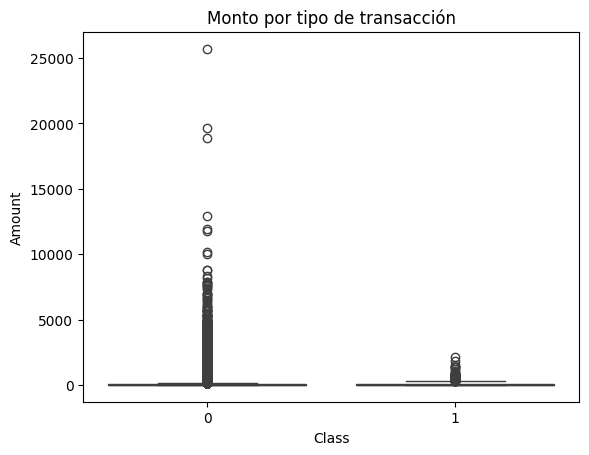

In [9]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Monto por tipo de transacción")
plt.show()

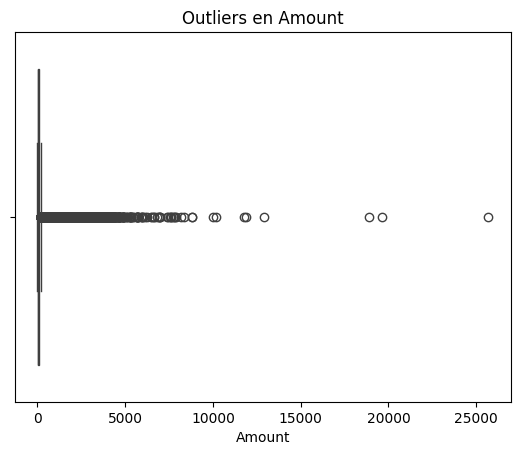

In [10]:
##Observar outliers en Amount

sns.boxplot(x=df['Amount'])
plt.title("Outliers en Amount")
plt.show()

In [11]:
## valores faltantes

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
##Proporción de clases
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

<Axes: xlabel='Amount', ylabel='Count'>

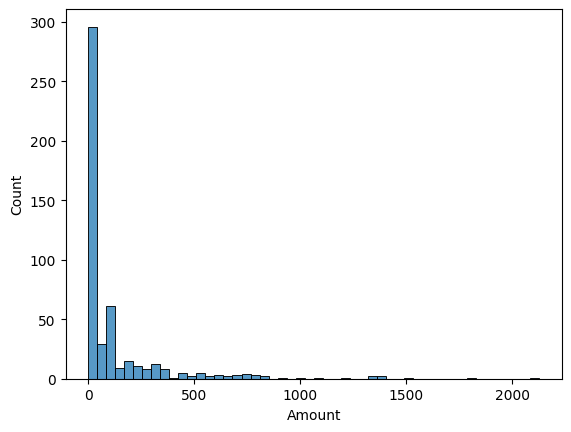

In [13]:
##Distribución de Amount para transacciones fraudulentas
sns.histplot(data=df[df.Class==1], x="Amount", bins=50)

# Hacer split y normalización

In [ ]:

# Separar variables (X) y target (y)
X = df.drop('Class', axis=1)  # todas las variables excepto la etiqueta
y = df['Class']               # variable objetivo (fraude o no)


# Dividir en train y test

# stratify=y asegura que el desbalance (fraude vs normal)
# se mantenga igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Definir qué columnas se van a escalar

# Solo escalamos Amount y Time porque:
# - V1–V28 ya vienen transformadas (PCA)
columnas_a_escalar = ['Amount', 'Time']


# Crear transformador
# ColumnTransformer permite aplicar transformaciones
# solo a ciertas columnas y dejar las demás intactas
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), columnas_a_escalar)  # escala solo estas columnas
    ],
    remainder='passthrough'  # deja el resto igual (V1–V28)
)

# Ajustar el scaler SOLO con train

# fit_transform aprende la media y desviación del train
# y transforma los datos (evita data leakage)
X_train_prepared = preprocessor.fit_transform(X_train)

# Transformar test SIN volver a ajustar
# solo aplica la misma transformación aprendida en train
X_test_prepared = preprocessor.transform(X_test)

# Modelos de Clasificacion a entrenar

## K- Nearest

In [ ]:
# # Usar el dataset de entrenamiento
# X_data = X_train_prepared
# y_data = y_train

# # Definir hiperparámetros
# lista_k = [1, 3, 5, 7, 9, 11, 15, 21, 31]
# lista_thresholds = np.arange(0.05, 0.55, 0.05)

# # Cross-validation estratificado, crea diferentes particion para la info de train y validation
# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# # Resultados
# resultados = []

# # Búsqueda de K + threshold
# for k in lista_k:
    
#     # Listas para almacenar el mejor resultado obtenido en cada fold
#     # para este valor actual de n_neighbors
#     recalls_folds = []
#     precisions_folds = []
#     thresholds_folds = []
    
#     # cv.split(...) genera los índices de train y validation
#     # para cada fold, preservando la proporción de clases
#     for train_idx, val_idx in cv.split(X_data, y_data):
        
#         # Se construyen los subconjuntos del fold actual:
#         # una parte para entrenamiento y otra para cross validation
#         X_fold_train = X_data[train_idx]
#         X_fold_val = X_data[val_idx]
#         y_fold_train = y_data.iloc[train_idx]
#         y_fold_val = y_data.iloc[val_idx]
        
#         # Se instancia el modelo KNN con el valor actual de k
#         # n_jobs=-1 permite usar todos los núcleos disponibles del CPU
#         # para acelerar el cálculo de vecinos
#         modelo_knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
        
#         # El modelo "aprende" almacenando los patrones del fold de entrenamiento;
#         # en KNN no se ajustan coeficientes, sino que se conserva el conjunto train
#         # para comparar distancias en la predicción
#         modelo_knn.fit(X_fold_train, y_fold_train)
        
#         # Se obtienen las probabilidades estimadas de la clase positiva (fraude)
#         # [:, 1] selecciona únicamente la probabilidad de pertenecer a la clase 1
#         y_proba_val = modelo_knn.predict_proba(X_fold_val)[:, 1]
        
#         # Variables para guardar la mejor combinación dentro de este fold:
#         # se busca el threshold que maximice recall cumpliendo precision >= 0.80
#         mejor_recall_fold = -1
#         mejor_precision_fold = 0
#         mejor_threshold_fold = None
        
#         # Se prueban distintos puntos de corte sobre las probabilidades predichas;
#         # esto convierte probabilidades en clases binarias
#         for threshold in lista_thresholds:
#             y_pred_val = (y_proba_val >= threshold).astype(int)
            
#             # Precision: de los casos predichos como fraude,
#             # cuántos realmente sí eran fraude
#             precision = precision_score(y_fold_val, y_pred_val, zero_division=0)
            
#             # Recall: de todos los fraudes reales,
#             # cuántos logró detectar el modelo
#             recall = recall_score(y_fold_val, y_pred_val, zero_division=0)
            
#             # Restricción de negocio/modelado:
#             # solo se consideran thresholds cuya precision sea al menos 0.80
#             if precision >= 0.80:
                
#                 # Entre los thresholds válidos, se conserva el que produzca
#                 # el mayor recall en este fold
#                 if recall > mejor_recall_fold:
#                     mejor_recall_fold = recall
#                     mejor_precision_fold = precision
#                     mejor_threshold_fold = threshold
        
#         # Si ningún threshold cumplió la restricción mínima de precision,
#         # se guarda 0 como resultado del fold y None para el threshold
#         if mejor_recall_fold == -1:
#             recalls_folds.append(0)
#             precisions_folds.append(0)
#             thresholds_folds.append(None)
#         else:
#             # Si sí hubo un threshold válido, se almacena el mejor resultado
#             # encontrado en este fold
#             recalls_folds.append(mejor_recall_fold)
#             precisions_folds.append(mejor_precision_fold)
#             thresholds_folds.append(mejor_threshold_fold)
    
#     # Se filtran solo los thresholds válidos (distintos de None)
#     # para poder calcular un promedio representativo
#     thresholds_validos = [t for t in thresholds_folds if t is not None]
    
#     # Se resume el desempeño promedio de este valor de k
#     # a través de todos los folds de la validación cruzada
#     resultados.append({
#         'n_neighbors': k,
#         'recall_promedio_cv': np.mean(recalls_folds),
#         'precision_promedio_cv': np.mean(precisions_folds),
#         'threshold_promedio_cv': np.mean(thresholds_validos) if len(thresholds_validos) > 0 else None
#     })
    
#     recalls_folds = []
#     precisions_folds = []
#     thresholds_folds = []
    
# # Resultados finales
# df_resultados_knn = pd.DataFrame(resultados).sort_values(
#     by='recall_promedio_cv',
#     ascending=False
# ).reset_index(drop=True)

# print(df_resultados_knn)

   n_neighbors  recall_promedio_cv  precision_promedio_cv  \
0            9            0.807117               0.833223   
1            7            0.802047               0.863686   
2            5            0.796977               0.881919   
3           11            0.796939               0.824352   
4           15            0.789344               0.816578   
5            1            0.784351               0.867324   
6           31            0.781672               0.828536   
7           21            0.779146               0.825972   
8            3            0.758906               0.914414   

   threshold_promedio_cv  
0               0.150000  
1               0.150000  
2               0.250000  
3               0.133333  
4               0.166667  
5               0.050000  
6               0.150000  
7               0.166667  
8               0.350000  


In [ ]:
# Crear el modelo final con los hiperparámetros elegidos
modelo_knn_final = KNeighborsClassifier(
    n_neighbors=11,
    n_jobs=-1
)

# Entrenar el modelo con TODO el set de entrenamiento
modelo_knn_final.fit(X_train_prepared, y_train)

# Obtener probabilidades sobre el set de prueba
y_proba_knn_final = modelo_knn_final.predict_proba(X_test_prepared)[:, 1]

# Aplicar el threshold elegido
# Entre mas bajo sea el threshold, mas casos se clasifican como fraude (recall aumenta, precision disminuye)
threshold_final = 0.10
y_pred_knn_final = (y_proba_knn_final >= threshold_final).astype(int)

# Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_knn_final))

# Classification report
print("\nClassification report:")
print(classification_report(y_test, y_pred_knn_final, digits=4))

# ROC-AUC debe ser mayor a 0.5 y entre más cercano a 1 mejor, mide la capacidad de separar clases
roc_auc_knn_final = roc_auc_score(y_test, y_proba_knn_final)
print("\nROC-AUC:", round(roc_auc_knn_final, 4))

# PR-AUC que tan bien detecta la clase positiva(fraudes) sin aumentar falsos positivos
pr_auc_knn_final = average_precision_score(y_test, y_proba_knn_final)
print("PR-AUC:", round(pr_auc_knn_final, 4))

Matriz de confusión:
[[56843    21]
 [   12    86]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997     56864
           1     0.8037    0.8776    0.8390        98

    accuracy                         0.9994     56962
   macro avg     0.9018    0.9386    0.9194     56962
weighted avg     0.9995    0.9994    0.9994     56962


ROC-AUC: 0.9488
PR-AUC: 0.8308


## Regresión Logistica

In [ ]:
# resultados_modelo = []

# # Valores del hiperparámetro C a evaluar
# # C controla la regularización:
# # valores pequeños -> mayor regularización (modelo más simple)
# # valores grandes -> menor regularización (modelo más flexible)
# valores_C = [0.01, 0.1, 1, 10, 100]

# for c in valores_C:

#     # Definición del modelo de regresión logística
#     modelo = LogisticRegression(
#         C=c,
#         penalty='l2',          # Regularización L2 (penaliza coeficientes grandes)
#         solver='liblinear',    # Solver adecuado para datasets pequeños/medianos y binarios
#         class_weight=None,     # No ajusta pesos para desbalanceo
#         max_iter=1000,         # Límite de iteraciones para convergencia
#         random_state=42
#     )

#     # Entrenamiento del modelo con TODO el set de entrenamiento
#     # Aquí se estiman los coeficientes (betas) que minimizan la función de pérdida
#     modelo.fit(X_train_prepared, y_train)

#     # Obtención de probabilidades de la clase positiva (fraude)
#     # Se usa el modelo logístico: sigmoid(Xβ)
#     probs = modelo.predict_proba(X_test_prepared)[:, 1]

#     # Aplicación de un threshold fijo (0.02) para convertir probabilidades a clases
#     # Threshold bajo -> aumenta recall, reduce precision
#     preds = (probs >= 0.02).astype(int)

#     # Matriz de confusión descompuesta:
#     # tn: verdaderos negativos
#     # fp: falsos positivos
#     # fn: falsos negativos
#     # tp: verdaderos positivos
#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     # Recall (sensibilidad):
#     # proporción de fraudes correctamente detectados
#     recall = tp / (tp + fn)

#     # False Positive Rate (FPR):
#     # proporción de no fraudes clasificados incorrectamente como fraude
#     fpr = fp / (fp + tn)

#     # Se almacenan los resultados para este valor de C
#     resultados_modelo.append({
#         "C": c,
#         "recall": recall,
#         "fpr": fpr,
#         "TP": tp,
#         "FP": fp,
#         "FN": fn,
#         "TN": tn
#     })

# # Conversión a DataFrame para análisis comparativo
# df_modelos = pd.DataFrame(resultados_modelo)

# # Ordenar modelos por recall descendente
# # Prioridad: maximizar detección de fraudes
# df_modelos = df_modelos.sort_values(
#     by="recall",
#     ascending=False
# ).reset_index(drop=True)

# print(df_modelos)

        C    recall       fpr  TP  FP  FN     TN
0    0.01  0.887755  0.001337  87  76  11  56788
1    0.10  0.887755  0.001213  87  69  11  56795
2    1.00  0.877551  0.001354  86  77  12  56787
3   10.00  0.877551  0.001372  86  78  12  56786
4  100.00  0.877551  0.001389  86  79  12  56785


In [ ]:
# # 1. Definir modelo para tresholds
# modelo_lr_final = LogisticRegression(
#     C=0.10,
#     penalty='l2',
#     solver='liblinear',
#     class_weight=None,
#     max_iter=1000,
#     random_state=42
# )

# # 2. Entrenar con TODO el train
# modelo_lr_final.fit(X_train_prepared, y_train)

# # 3. Obtener probabilidades en test
# probabilidades_test = modelo_lr_final.predict_proba(X_test_prepared)[:, 1]

# # 4. Probar varios thresholds
# thresholds = np.arange(0.01, 0.06, 0.005)

# resultados_threshold = []

# for threshold in thresholds:
#     predicciones_test = (probabilidades_test >= threshold).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

#     recall = tp / (tp + fn)
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     fpr = fp / (fp + tn)

#     resultados_threshold.append({
#         "threshold": threshold,
#         "TN": tn,
#         "FP": fp,
#         "FN": fn,
#         "TP": tp,
#         "recall": recall,
#         "precision": precision,
#         "fpr": fpr
#     })

# df_thresholds_final = pd.DataFrame(resultados_threshold)

# print(df_thresholds_final)

   threshold     TN   FP  FN  TP    recall  precision       fpr
0      0.010  56645  219  11  87  0.887755   0.284314  0.003851
1      0.015  56759  105  11  87  0.887755   0.453125  0.001847
2      0.020  56795   69  11  87  0.887755   0.557692  0.001213
3      0.025  56806   58  12  86  0.877551   0.597222  0.001020
4      0.030  56813   51  15  83  0.846939   0.619403  0.000897
5      0.035  56819   45  15  83  0.846939   0.648438  0.000791
6      0.040  56822   42  15  83  0.846939   0.664000  0.000739
7      0.045  56824   40  15  83  0.846939   0.674797  0.000703
8      0.050  56825   39  15  83  0.846939   0.680328  0.000686
9      0.055  56826   38  15  83  0.846939   0.685950  0.000668


In [ ]:
# Definir modelo final de regresión logística con los hiperparámetros seleccionados
modelo_lr_final = LogisticRegression(
    C=0.10,                 # Inversa de la regularización: valor bajo -> mayor penalización (modelo más simple)
    penalty='l2',           # Regularización L2: evita coeficientes grandes (control de overfitting)
    solver='liblinear',     # Algoritmo de optimización adecuado para problemas binarios
    class_weight=None,      # No se ajustan pesos por desbalance (se podría usar 'balanced')
    max_iter=1000,          # Número máximo de iteraciones para asegurar convergencia
    random_state=42
)

# Entrenamiento con TODO el conjunto de entrenamiento
modelo_lr_final.fit(X_train_prepared, y_train)

# Obtención de probabilidades de la clase positiva (fraude)
probabilidades_test_lr = modelo_lr_final.predict_proba(X_test_prepared)[:, 1]

# Aplicación del threshold final para convertir probabilidades en clases binarias
# Threshold bajo (0.025) -> favorece recall alto a costa de precision
threshold_final = 0.025
probabilidades_test_lr = (probabilidades_test_lr >= threshold_final).astype(int)

# Construcción de la matriz de confusión
matriz_confusion = confusion_matrix(y_test, probabilidades_test_lr)
tn, fp, fn, tp = matriz_confusion.ravel()

# Recall (sensibilidad):
# proporción de fraudes reales correctamente detectados
recall = tp / (tp + fn)

# Precision:
# proporción de predicciones de fraude que realmente lo son
# Se protege contra división entre cero
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

# False Positive Rate (FPR):
# proporción de no fraudes incorrectamente clasificados como fraude
fpr = fp / (fp + tn)

# Classification report:
reporte_clasificacion = classification_report(y_test, probabilidades_test_lr, zero_division=0)

print("Matriz de confusión:")
print(matriz_confusion)

print("\nMétricas clave:")
print(f"FPR: {fpr:.6f}")

print("\nClassification report:")
print(reporte_clasificacion)

Matriz de confusión:
[[56806    58]
 [   12    86]]

Métricas clave:
Recall (clase 1): 0.877551
Precision (clase 1): 0.597222
FPR: 0.001020

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.60      0.88      0.71        98

    accuracy                           1.00     56962
   macro avg       0.80      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Average Precision Score: 0.524304


## SVM RBF

In [20]:
# # --------------------------------------------------------
# # 0. Crear sample estratificado del TRAIN
# # --------------------------------------------------------
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.2,        # usa 20%
#     stratify=y_train,
#     random_state=42
# )

# # --------------------------------------------------------
# # 1. Modelo base SVC con kernel RBF
# # --------------------------------------------------------
# modelo_svc_rbf = SVC(
#     kernel='rbf',
#     C=1.0,
#     gamma='scale',
#     probability=True,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenamiento (con SAMPLE, no todo el dataset)
# # --------------------------------------------------------
# modelo_svc_rbf.fit(X_train_sample, y_train_sample)

# # --------------------------------------------------------
# # 3. Predicciones (SIEMPRE sobre test completo)
# # --------------------------------------------------------
# probs = modelo_svc_rbf.predict_proba(X_test_prepared)[:, 1]

# threshold = 0.02
# preds = (probs >= threshold).astype(int)

# # --------------------------------------------------------
# # 4. Evaluación
# # --------------------------------------------------------
# print("Matriz de confusión:")
# print(confusion_matrix(y_test, preds))

# print("\nClassification report:")
# print(classification_report(y_test, preds))

# print("\nAverage precision score:")
# print(average_precision_score(y_test, probs))

In [ ]:
# # Se toma una muestra estratificada del set de entrenamiento para reducir costo computacional manteniendo proporción de clases
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.1,
#     stratify=y_train,
#     random_state=42
# )

# # Definición del espacio de búsqueda de hiperparámetros C (regularización) y gamma (influencia de cada punto en RBF)
# valores_C = [0.1, 1, 10]
# valores_gamma = ['scale', 0.01, 0.1, 1]

# # Threshold aplicado sobre el decision_function; en SVM el valor 0 representa la frontera de decisión natural
# threshold = 0.0

# resultados = []

# # Iteración sobre todas las combinaciones de C y gamma (búsqueda manual tipo grid search)
# for c in valores_C:
#     for g in valores_gamma:

#         # Definición del modelo SVM con kernel RBF; probability=False evita cálculo costoso de probabilidades
#         modelo = SVC(
#             kernel='rbf',
#             C=c,
#             gamma=g,
#             probability=False,
#             random_state=42
#         )

#         # Entrenamiento del modelo; SVM encuentra el hiperplano óptimo maximizando el margen
#         modelo.fit(X_train_sample, y_train_sample)

#         # decision_function devuelve la distancia al hiperplano; valores positivos indican clase 1
#         scores = modelo.decision_function(X_test_prepared)

#         # Aplicación del threshold sobre los scores para convertirlos en clases binarias
#         preds = (scores >= threshold).astype(int)

#         # Descomposición de la matriz de confusión en sus componentes básicos
#         tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#         # Precision mide qué proporción de predicciones positivas son correctas
#         precision = precision_score(y_test, preds, zero_division=0)

#         # Recall mide qué proporción de los positivos reales fueron detectados
#         recall = recall_score(y_test, preds, zero_division=0)

#         # F1-score balancea precision y recall mediante media armónica
#         f1 = f1_score(y_test, preds, zero_division=0)

#         # False Positive Rate mide proporción de negativos clasificados incorrectamente como positivos
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         # Se almacenan métricas y componentes de la matriz de confusión para análisis comparativo
#         resultados.append({
#             "C": c,
#             "gamma": g,
#             "precision": precision,
#             "recall": recall,
#             "f1_score": f1,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp,
#             "matriz_confusion": [[tn, fp], [fn, tp]]
#         })

# # Conversión de resultados a DataFrame para facilitar análisis
# df_resultados_svc_rbf = pd.DataFrame(resultados)

# # Ordenamiento priorizando recall y luego precision para favorecer detección de fraudes
# df_resultados_svc_rbf = df_resultados_svc_rbf.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_resultados_svc_rbf)

       C  gamma  precision    recall  f1_score       fpr     tn  fp  fn  tp  \
0   10.0   0.01   0.847059  0.734694  0.786885  0.000229  56851  13  26  72   
1    1.0   0.01   0.875000  0.642857  0.741176  0.000158  56855   9  35  63   
2   10.0  scale   0.869565  0.408163  0.555556  0.000106  56858   6  58  40   
3    1.0  scale   0.878788  0.295918  0.442748  0.000070  56860   4  69  29   
4   10.0    0.1   1.000000  0.122449  0.218182  0.000000  56864   0  86  12   
5    1.0    0.1   1.000000  0.071429  0.133333  0.000000  56864   0  91   7   
6    1.0      1   1.000000  0.051020  0.097087  0.000000  56864   0  93   5   
7   10.0      1   1.000000  0.051020  0.097087  0.000000  56864   0  93   5   
8    0.1  scale   0.000000  0.000000  0.000000  0.000000  56864   0  98   0   
9    0.1   0.01   0.000000  0.000000  0.000000  0.000000  56864   0  98   0   
10   0.1    0.1   0.000000  0.000000  0.000000  0.000000  56864   0  98   0   
11   0.1      1   0.000000  0.000000  0.000000  0.00

In [ ]:
# ##Econtrar el treshold

# # --------------------------------------------------------
# # 1. Entrenar modelo final con mejores hiperparámetros
# # --------------------------------------------------------
# modelo_final = SVC(
#     kernel='rbf',
#     C=10,
#     gamma=0.01,
#     probability=False,
#     random_state=42
# )

# modelo_final.fit(X_train_sample, y_train_sample)

# # --------------------------------------------------------
# # 2. Obtener scores
# # --------------------------------------------------------
# scores = modelo_final.decision_function(X_test_prepared)

# # --------------------------------------------------------
# # 3. Probar distintos thresholds
# # --------------------------------------------------------
# thresholds = np.linspace(scores.min(), scores.max(), 200)

# resultados_threshold = []

# for t in thresholds:
#     preds = (scores >= t).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     precision = precision_score(y_test, preds, zero_division=0)
#     recall = recall_score(y_test, preds, zero_division=0)
#     f1 = f1_score(y_test, preds, zero_division=0)
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados_threshold.append({
#         "threshold": t,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 4. Crear DataFrame con resultados
# # --------------------------------------------------------
# df_thresholds = pd.DataFrame(resultados_threshold)

# # --------------------------------------------------------
# # 5. Filtrar thresholds con FPR menor a 5%
# # --------------------------------------------------------
# df_fpr_menor_5 = df_thresholds[df_thresholds["fpr"] < 0.01].copy()

# # --------------------------------------------------------
# # 6. Elegir el mejor:
# #    primero mayor recall, luego mayor precision
# # --------------------------------------------------------
# df_fpr_menor_5 = df_fpr_menor_5.sort_values(
#     by=["fpr",],
#     ascending=[False]
# ).reset_index(drop=True)

# df_fpr_menor_5

In [ ]:
# 1. Modelo final SVC con kernel RBF
modelo_svc_rbf_final = SVC(
    kernel='rbf',
    C=10,
    gamma=0.01,
    probability=False,
    random_state=42
)

# Entrenamiento con TODO el set de entrenamiento
modelo_svc_rbf_final.fit(X_train_prepared, y_train)

# Scores y predicciones en test
scores_final_rbf = modelo_svc_rbf_final.decision_function(X_test_prepared)

# En svm el trehsold puede ser negativo, ya que no esta calibrado por probabilidades
threshold_final = -0.72
preds_final = (scores_final_rbf >= threshold_final).astype(int)

# Métricas
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()

precision = precision_score(y_test, preds_final, zero_division=0)
recall = recall_score(y_test, preds_final, zero_division=0)
f1 = f1_score(y_test, preds_final, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# Resultados
print("Threshold final:", threshold_final)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, preds_final))

print("\nClassification report:")
print(classification_report(y_test, preds_final))

print("\nResumen de métricas:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"FPR:       {fpr:.4%}")

Threshold final: -0.72

Matriz de confusión:
[[56850    14]
 [   13    85]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.87      0.86        98

    accuracy                           1.00     56962
   macro avg       0.93      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Resumen de métricas:
Precision: 0.8586
Recall:    0.8673
F1-score:  0.8629
FPR:       0.0246%


## SVM Lineal

In [24]:
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_prepared,
    y_train,
    train_size=0.2,        # usa 20%
    stratify=y_train,
    random_state=42
)

In [25]:
# # --------------------------------------------------------
# # 1. Modelo LinearSVC
# # --------------------------------------------------------

# modelo_linear = LinearSVC(
#     C=1.0,
#     max_iter=5000,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenamiento
# # --------------------------------------------------------
# modelo_linear.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Scores y predicciones
# # --------------------------------------------------------
# scores = modelo_linear.decision_function(X_test_prepared)

# threshold = 0.0
# preds = (scores >= threshold).astype(int)

# # --------------------------------------------------------
# # 4. Métricas
# # --------------------------------------------------------
# tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

# precision = precision_score(y_test, preds, zero_division=0)
# recall = recall_score(y_test, preds, zero_division=0)
# f1 = f1_score(y_test, preds, zero_division=0)
# fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# # --------------------------------------------------------
# # 5. Resultados
# # --------------------------------------------------------
# print("Matriz de confusión:")
# print(confusion_matrix(y_test, preds))

# print("\nClassification report:")
# print(classification_report(y_test, preds))

# print("\nResumen de métricas:")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-score:  {f1:.4f}")
# print(f"FPR:       {fpr:.4%}")

In [ ]:
# # Definición de valores del hiperparámetro C que controla la regularización del modelo lineal
# valores_C = [0.01, 0.1, 1, 10, 100]

# # Uso de class_weight='balanced' para ajustar automáticamente los pesos inversamente proporcionales a la frecuencia de clases
# class_weights = ['balanced']

# # Threshold aplicado sobre decision_function; en modelos lineales el valor 0 es la frontera de decisión
# threshold = 0.0

# resultados = []

# for cw in class_weights:
#     for c in valores_C:

#         modelo = LinearSVC(
#             C=c,                  
#             class_weight=cw,      
#             dual=False,           # Usa formulación primal (más eficiente cuando n_samples > n_features)
#             max_iter=5000,        # Aumenta iteraciones para asegurar convergencia
#             random_state=42
#         )

#         # Entrenamiento del modelo; se optimiza el margen maximizando separación entre clases
#         modelo.fit(X_train_prepared, y_train)

#         # decision_function devuelve distancia al hiperplano; valores positivos indican clase 1
#         scores = modelo.decision_function(X_test_prepared)

#         # Conversión de scores a clases binarias usando threshold definido
#         preds = (scores >= threshold).astype(int)

#         # Extracción de componentes de la matriz de confusión
#         tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#         # Precision mide la proporción de positivos predichos que son correctos
#         precision = precision_score(y_test, preds, zero_division=0)

#         # Recall mide la proporción de positivos reales correctamente detectados
#         recall = recall_score(y_test, preds, zero_division=0)

#         # F1-score combina precision y recall en una sola métrica balanceada
#         f1 = f1_score(y_test, preds, zero_division=0)

#         # FPR mide la proporción de negativos clasificados incorrectamente como positivos
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         resultados.append({
#             "C": c,
#             "class_weight": cw,
#             "precision": precision,
#             "recall": recall,
#             "f1_score": f1,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp,
#             "matriz_confusion": [[tn, fp], [fn, tp]]
#         })

# df_resultados_linearsvc = pd.DataFrame(resultados)

# df_resultados_linearsvc = df_resultados_linearsvc.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_resultados_linearsvc)

In [27]:
# # --------------------------------------------------------
# # 1. Entrenar modelo con C = 1 y buscar el treshold óptimo
# # --------------------------------------------------------
# modelo_linearsvc_final = LinearSVC(
#     C=1,
#     class_weight='balanced',
#     dual=False,
#     max_iter=5000,
#     random_state=42
# )

# modelo_linearsvc_final.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 2. Obtener scores
# # --------------------------------------------------------
# scores = modelo_linearsvc_final.decision_function(X_test_prepared)

# # --------------------------------------------------------
# # 3. Probar diferentes thresholds
# # --------------------------------------------------------
# thresholds = np.linspace(scores.min(), scores.max(), 200)

# resultados_threshold = []

# for t in thresholds:
#     preds = (scores >= t).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     precision = precision_score(y_test, preds, zero_division=0)
#     recall = recall_score(y_test, preds, zero_division=0)
#     f1 = f1_score(y_test, preds, zero_division=0)
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados_threshold.append({
#         "threshold": t,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp,
#         "matriz_confusion": [[tn, fp], [fn, tp]]
#     })

# # --------------------------------------------------------
# # 4. DataFrame final
# # --------------------------------------------------------
# df_thresholds_linearsvc = pd.DataFrame(resultados_threshold)

# df_thresholds_linearsvc = df_thresholds_linearsvc.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# df_thresholds_linearsvc_fpr_5 = df_thresholds_linearsvc[
#     df_thresholds_linearsvc["fpr"] < 0.05
# ].copy()

# df_thresholds_linearsvc_fpr_5 = df_thresholds_linearsvc_fpr_5.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_thresholds_linearsvc_fpr_5.head(10))

In [ ]:
# 1. Modelo final
modelo_linearsvc_final = LinearSVC(
    C=1,
    class_weight='balanced',
    dual=False,
    max_iter=5000,
    random_state=42
)

# 2. Entrenamiento con TODO el train
modelo_linearsvc_final.fit(X_train_prepared, y_train)

# 3. Scores y predicciones
scores_final_lineal = modelo_linearsvc_final.decision_function(X_test_prepared)

threshold_final = 0.90
preds_final = (scores_final_lineal >= threshold_final).astype(int)

# 4. Métricas
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()

precision = precision_score(y_test, preds_final, zero_division=0)
recall = recall_score(y_test, preds_final, zero_division=0)
f1 = f1_score(y_test, preds_final, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# 5. Resultados
print("Threshold final:", threshold_final)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, preds_final))

print("\nClassification report:")
print(classification_report(y_test, preds_final))

print("\nResumen de métricas:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"FPR:       {fpr:.4%}")

Threshold final: 0.9

Matriz de confusión:
[[56760   104]
 [   11    87]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.89      0.60        98

    accuracy                           1.00     56962
   macro avg       0.73      0.94      0.80     56962
weighted avg       1.00      1.00      1.00     56962


Resumen de métricas:
Precision: 0.4555
Recall:    0.8878
F1-score:  0.6021
FPR:       0.1829%


## SVM Poly

In [29]:
# # --------------------------------------------------------
# # 1. Modelo base SVC con kernel poly
# # --------------------------------------------------------
# modelo_svc_poly = SVC(
#     kernel='poly',
#     C=1,
#     degree=3,
#     gamma='scale',
#     coef0=0,
#     probability=False,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenamiento con TODO el dataset
# # --------------------------------------------------------
# modelo_svc_poly.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Scores y predicciones
# # --------------------------------------------------------
# scores = modelo_svc_poly.decision_function(X_test_prepared)

# threshold = 0.0
# preds = (scores >= threshold).astype(int)

# # --------------------------------------------------------
# # 4. Métricas
# # --------------------------------------------------------
# tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

# precision = precision_score(y_test, preds, zero_division=0)
# recall = recall_score(y_test, preds, zero_division=0)
# f1 = f1_score(y_test, preds, zero_division=0)
# fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

# # --------------------------------------------------------
# # 5. Resultados
# # --------------------------------------------------------
# print("Matriz de confusión:")
# print(confusion_matrix(y_test, preds))

# print("\nClassification report:")
# print(classification_report(y_test, preds))

# print("\nResumen de métricas:")
# print(f"Precision: {precision:.4f}")
# print(f"Recall:    {recall:.4f}")
# print(f"F1-score:  {f1:.4f}")
# print(f"FPR:       {fpr:.4%}")

In [ ]:
# # Se toma una muestra estratificada del set de 
# X_train_sample, _, y_train_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.2,
#     stratify=y_train,
#     random_state=42
# )

# valores_C = [0.1, 1, 10]
# valores_degree = [2,3,4,5]  # degree=1 equivaldría a un kernel lineal

# threshold = 0.0

# resultados = []

# for c in valores_C:
#     for d in valores_degree:

#         # Definición del modelo SVM con kernel polinomial; transforma el espacio a dimensiones superiores
#         modelo = SVC(
#             kernel='poly',
#             C=c,              
#             degree=d,         # Grado del polinomio; mayor grado -> mayor capacidad de modelar relaciones no lineales
#             gamma='scale',    # Factor de escalamiento automático basado en número de features
#             coef0=0,          # Término independiente del kernel polinomial; afecta curvatura del modelo
#             probability=False, # Evita cálculo de probabilidades para reducir costo computacional
#             random_state=42
#         )

#         # Entrenamiento del modelo; se optimiza el margen en el espacio transformado por el kernel
#         modelo.fit(X_train_sample, y_train_sample)

#         # decision_function devuelve la distancia al hiperplano en el espacio transformado
#         scores = modelo.decision_function(X_test_prepared)

#         # Conversión de scores a clases binarias usando el threshold definido
#         preds = (scores >= threshold).astype(int)

#         # Descomposición de la matriz de confusión en sus componentes básicos
#         tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#         precision = precision_score(y_test, preds, zero_division=0)

#         recall = recall_score(y_test, preds, zero_division=0)

#         f1 = f1_score(y_test, preds, zero_division=0)

#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         resultados.append({
#             "C": c,
#             "degree": d,
#             "precision": precision,
#             "recall": recall,
#             "f1_score": f1,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp,
#             "matriz_confusion": [[tn, fp], [fn, tp]]
#         })

# df_resultados_poly = pd.DataFrame(resultados)

# df_resultados_poly = df_resultados_poly.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_resultados_poly)

In [31]:
# # --------------------------------------------------------
# # 1. Modelo final con mejores hiperparámetros
# # --------------------------------------------------------
# modelo_poly_final = SVC(
#     kernel='poly',
#     C=0.1,
#     degree=2,
#     gamma='scale',
#     coef0=0,
#     probability=False,
#     random_state=42
# )

# modelo_poly_final.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 2. Obtener scores
# # --------------------------------------------------------
# scores = modelo_poly_final.decision_function(X_test_prepared)

# # --------------------------------------------------------
# # 3. Probar thresholds
# # --------------------------------------------------------
# thresholds = np.linspace(scores.min(), scores.max(), 200)

# resultados = []

# for t in thresholds:

#     preds = (scores >= t).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     precision = precision_score(y_test, preds, zero_division=0)
#     recall = recall_score(y_test, preds, zero_division=0)
#     f1 = f1_score(y_test, preds, zero_division=0)
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados.append({
#         "threshold": t,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 4. DataFrame
# # --------------------------------------------------------
# df_thresholds_poly = pd.DataFrame(resultados)

# # --------------------------------------------------------
# # 5. Filtrar por FPR < 5%
# # --------------------------------------------------------
# df_validos = df_thresholds_poly[df_thresholds_poly["fpr"] < 0.05].copy()

# # ordenar por mejor recall y precision
# df_validos = df_validos.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_validos.head(10))

# # --------------------------------------------------------
# # 6. Mejor threshold
# # --------------------------------------------------------
# mejor_threshold = df_validos.loc[0, "threshold"]

# print("\nMejor threshold:", mejor_threshold)

In [ ]:
# 1. Modelo final SVM poly
modelo_svc_poly_final = SVC(
    kernel='poly',
    C=0.1,
    degree=2, ##Degree de 1 seria lineal
    gamma='scale', # Factor de escalamiento automático basado en número de features
    coef0=0,  # Término independiente del kernel polinomial; afecta curvatura del modelo
    probability=False,
    random_state=42
)

# 2. Entrenamiento con todo el set de entrenamiento
modelo_svc_poly_final.fit(X_train_prepared, y_train)

# 3. Scores y predicciones
scores_final_poly = modelo_svc_poly_final.decision_function(X_test_prepared)

# En svm el trehsold puede ser negativo, ya que no esta calibrado por probabilidades
threshold_final = -0.5
preds_final = (scores_final_poly >= threshold_final).astype(int)

# 4. Métricas
tn, fp, fn, tp = confusion_matrix(y_test, preds_final).ravel()

precision = precision_score(y_test, preds_final, zero_division=0)
recall = recall_score(y_test, preds_final, zero_division=0)
f1 = f1_score(y_test, preds_final, zero_division=0)
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, preds_final))

print("\nClassification report:")
print(classification_report(y_test, preds_final))

print("\nResumen de métricas:")
print(f"FPR:       {fpr:.4%}")

Threshold final: -0.5

Matriz de confusión:
[[56851    13]
 [   22    76]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.78      0.81        98

    accuracy                           1.00     56962
   macro avg       0.93      0.89      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Resumen de métricas:
Precision: 0.8539
Recall:    0.7755
F1-score:  0.8128
FPR:       0.0229%


## Decision trees

In [33]:
# # --------------------------------------------------------
# # 1. Definir modelo base (simple, sin tuning)
# # --------------------------------------------------------
# modelo_dt = DecisionTreeClassifier(
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenar con TODO el train
# # --------------------------------------------------------
# modelo_dt.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Predicciones (default threshold = 0.5)
# # --------------------------------------------------------
# predicciones_test = modelo_dt.predict(X_test_prepared)

# # Probabilidades (para después usar threshold tuning)
# probabilidades_test = modelo_dt.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 4. Evaluación
# # --------------------------------------------------------
# tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

# recall = tp / (tp + fn)
# precision = tp / (tp + fp)
# fpr = fp / (fp + tn)

# print("Confusion Matrix:")
# print(confusion_matrix(y_test, predicciones_test))

# print("\nClassification Report:")
# print(classification_report(y_test, predicciones_test))

# print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test))
# print("PR-AUC:", average_precision_score(y_test, probabilidades_test))

# print("\nResumen:")
# print(f"Recall: {recall:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"FPR: {fpr:.4f}")

In [ ]:
# # Definición del espacio de hiperparámetros para controlar complejidad y regularización del árbol
# param_grid = {
#     "max_depth": [3, 5, 10, 15, None],                 # Profundidad máxima del árbol; None permite crecer sin restricción
#     "min_samples_leaf": [1, 5, 10, 20],                # Mínimo de muestras en hojas para evitar nodos muy específicos
#     "min_samples_split": [2, 10, 20],                  # Mínimo de muestras requeridas para dividir un nodo
#     "class_weight": [None, "balanced"]                 # Ajuste de pesos para manejar desbalance de clases
# }

# resultados = []

# for max_depth in param_grid["max_depth"]:
#     for min_samples_leaf in param_grid["min_samples_leaf"]:
#         for min_samples_split in param_grid["min_samples_split"]:
#             for class_weight in param_grid["class_weight"]:

#                 # Definición del modelo Decision Tree con hiperparámetros específicos
#                 modelo = DecisionTreeClassifier(
#                     max_depth=max_depth,
#                     min_samples_leaf=min_samples_leaf,
#                     min_samples_split=min_samples_split,
#                     class_weight=class_weight,
#                     random_state=42
#                 )

#                 # Entrenamiento del modelo; el árbol aprende reglas de decisión recursivas para separar clases
#                 modelo.fit(X_train_prepared, y_train)

#                 # Obtención de probabilidades de la clase positiva basadas en proporciones en nodos hoja
#                 probabilidades = modelo.predict_proba(X_test_prepared)[:, 1]

#                 # Aplicación de threshold fijo para convertir probabilidades en clases binarias
#                 threshold = 0.5
#                 predicciones = (probabilidades >= threshold).astype(int)

#                 # Extracción de componentes de la matriz de confusión
#                 tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

#                 recall = tp / (tp + fn) if (tp + fn) > 0 else 0

#                 precision = tp / (tp + fp) if (tp + fp) > 0 else 0

#                 fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#                 resultados.append({
#                     "max_depth": max_depth,
#                     "min_samples_leaf": min_samples_leaf,
#                     "min_samples_split": min_samples_split,
#                     "class_weight": class_weight,
#                     "recall": recall,
#                     "precision": precision,
#                     "fpr": fpr,
#                     "tn": tn,
#                     "fp": fp,
#                     "fn": fn,
#                     "tp": tp
#                 })

# df_resultados = pd.DataFrame(resultados)

# df_resultados = df_resultados.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_resultados.head(10))

In [35]:
# # --------------------------------------------------------
# # 1. Definir lista de thresholds a probar
# # --------------------------------------------------------
# thresholds = np.arange(0.1, 1.0, 0.05)

# # --------------------------------------------------------
# # 2. Definir los 2 modelos finales
# # --------------------------------------------------------
# modelos = {
#     "modelo_1": DecisionTreeClassifier(
#         max_depth=None,
#         min_samples_leaf=20,
#         min_samples_split=20,
#         class_weight="balanced",
#         random_state=42
#     ),
    
#     "modelo_2": DecisionTreeClassifier(
#         max_depth=5,
#         min_samples_leaf=1,
#         min_samples_split=20,
#         class_weight=None,
#         random_state=42
#     )
# }

# # --------------------------------------------------------
# # 3. Lista para guardar resultados
# # --------------------------------------------------------
# resultados = []

# # --------------------------------------------------------
# # 4. Entrenar cada modelo y probar thresholds
# # --------------------------------------------------------
# for nombre_modelo, modelo in modelos.items():
    
#     # Entrenar
#     modelo.fit(X_train_prepared, y_train)
    
#     # Obtener probabilidades
#     probabilidades = modelo.predict_proba(X_test_prepared)[:, 1]
    
#     # Probar distintos thresholds
#     for threshold in thresholds:
#         predicciones = (probabilidades >= threshold).astype(int)
        
#         tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
        
#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         f1_score = (
#             2 * precision * recall / (precision + recall)
#             if (precision + recall) > 0 else 0
#         )
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        
#         resultados.append({
#             "modelo": nombre_modelo,
#             "threshold": round(threshold, 2),
#             "recall": recall,
#             "precision": precision,
#             "f1_score": f1_score,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp
#         })

# # --------------------------------------------------------
# # 5. Convertir resultados a DataFrame
# # --------------------------------------------------------
# df_thresholds = pd.DataFrame(resultados)

# # --------------------------------------------------------
# # 6. Ordenar por modelo, recall y precision
# # --------------------------------------------------------
# df_thresholds = df_thresholds.sort_values(
#     by=["modelo", "recall", "precision"],
#     ascending=[True, False, False]
# ).reset_index(drop=True)

# # --------------------------------------------------------
# # 7. Ver resultados
# # --------------------------------------------------------
# display(df_thresholds)

# # --------------------------------------------------------
# # 8. Ver top 10 por cada modelo
# # --------------------------------------------------------
# print("\nTop 10 - Modelo 1")
# display(
#     df_thresholds[df_thresholds["modelo"] == "modelo_1"]
#     .sort_values(by=["recall", "precision"], ascending=[False, False])
#     .head(10)
# )

# print("\nTop 10 - Modelo 2")
# display(
#     df_thresholds[df_thresholds["modelo"] == "modelo_2"]
#     .sort_values(by=["recall", "precision"], ascending=[False, False])
#     .head(10)
# )

In [ ]:
# Definición del modelo final Decision Tree con hiperparámetros seleccionados para controlar complejidad y evitar overfitting

modelo_dt_final = DecisionTreeClassifier(
    max_depth=5,              # Limita la profundidad del árbol para evitar sobreajuste
    min_samples_leaf=1,       # Permite hojas con una sola muestra (alta flexibilidad)
    min_samples_split=20,     # Requiere al menos 20 muestras para dividir un nodo (regularización)
    class_weight=None,        # No ajusta pesos por desbalance de clases
    random_state=42
)

# Entrenamiento del modelo usando TODO el conjunto de entrenamiento
modelo_dt_final.fit(X_train_prepared, y_train)

# Obtención de probabilidades de la clase positiva basadas en proporciones de clases en los nodos hoja
probabilidades_test_DT = modelo_dt_final.predict_proba(X_test_prepared)[:, 1]

# Aplicación del threshold final para convertir probabilidades en predicciones binarias
threshold_final = 0.35
predicciones_test = (probabilidades_test_DT >= threshold_final).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

recall = tp / (tp + fn)

precision = tp / (tp + fp)

fpr = fp / (fp + tn)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones_test))

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evalúa la capacidad de separación del modelo usando probabilidades en todos los thresholds posibles
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_DT))

# PR-AUC evalúa el desempeño en la clase positiva considerando la relación precision-recall
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_DT))

print("\nResumen:")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"FPR: {fpr:.4f}")

Confusion Matrix:
[[56854    10]
 [   17    81]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.9029419818715331
PR-AUC: 0.7603599767799766

Resumen:
Recall: 0.8265
Precision: 0.8901
FPR: 0.0002


## Random Forest

In [37]:
# # --------------------------------------------------------
# # 1. Definir modelo base
# # --------------------------------------------------------
# modelo_rf = RandomForestClassifier(
#     random_state=42,
#     n_estimators=100
# )

# # --------------------------------------------------------
# # 2. Entrenar con TODO el train
# # --------------------------------------------------------
# modelo_rf.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Predicciones con threshold default = 0.5
# # --------------------------------------------------------
# predicciones_test = modelo_rf.predict(X_test_prepared)

# # Probabilidades para métricas y futuros thresholds
# probabilidades_test = modelo_rf.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 4. Evaluación
# # --------------------------------------------------------
# tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

# recall = tp / (tp + fn)
# precision = tp / (tp + fp)
# fpr = fp / (fp + tn)

# print("Confusion Matrix:")
# print(confusion_matrix(y_test, predicciones_test))

# print("\nClassification Report:")
# print(classification_report(y_test, predicciones_test))

# print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test))
# print("PR-AUC:", average_precision_score(y_test, probabilidades_test))

# print("\nResumen:")
# print(f"Recall: {recall:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"FPR: {fpr:.4f}")

In [38]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import confusion_matrix

# # --------------------------------------------------------
# # 1. Crear sample estratificado del train
# # --------------------------------------------------------
# X_sample, _, y_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.20,   # puedes bajar a 0.20 si sigue tardando mucho
#     stratify=y_train,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Grid optimizado
# # --------------------------------------------------------
# param_grid = {
#     "n_estimators": [5,10,15,30],
#     "max_depth": [1,3, None],
#     "max_features": ["sqrt", 0.5],
#     "min_samples_leaf": [5],
#     "class_weight": ["balanced"]
# }

# # --------------------------------------------------------
# # 3. Lista para guardar resultados
# # --------------------------------------------------------
# resultados = []

# # --------------------------------------------------------
# # 4. Loop de combinaciones
# # --------------------------------------------------------
# for n_estimators in param_grid["n_estimators"]:
#     for max_depth in param_grid["max_depth"]:
#         for max_features in param_grid["max_features"]:
#             for min_samples_leaf in param_grid["min_samples_leaf"]:
#                 for class_weight in param_grid["class_weight"]:

#                     modelo = RandomForestClassifier(
#                         n_estimators=n_estimators,
#                         max_depth=max_depth,
#                         max_features=max_features,
#                         min_samples_leaf=min_samples_leaf,
#                         class_weight=class_weight,
#                         n_jobs=-1,
#                         random_state=42
#                     )

#                     # Entrenar con sample
#                     modelo.fit(X_sample, y_sample)

#                     # Probabilidades sobre test completo
#                     probabilidades = modelo.predict_proba(X_test_prepared)[:, 1]

#                     # Threshold base
#                     predicciones = (probabilidades >= 0.5).astype(int)

#                     # Métricas
#                     tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

#                     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#                     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#                     f1_score = (
#                         2 * precision * recall / (precision + recall)
#                         if (precision + recall) > 0 else 0
#                     )
#                     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#                     resultados.append({
#                         "n_estimators": n_estimators,
#                         "max_depth": max_depth,
#                         "max_features": max_features,
#                         "min_samples_leaf": min_samples_leaf,
#                         "class_weight": class_weight,
#                         "recall": recall,
#                         "precision": precision,
#                         "f1_score": f1_score,
#                         "fpr": fpr,
#                         "tn": tn,
#                         "fp": fp,
#                         "fn": fn,
#                         "tp": tp
#                     })

# # --------------------------------------------------------
# # 5. Convertir a DataFrame
# # --------------------------------------------------------
# df_resultados_rf = pd.DataFrame(resultados)

# # --------------------------------------------------------
# # 6. Ordenar por recall y precision
# # --------------------------------------------------------
# df_resultados_rf = df_resultados_rf.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# # --------------------------------------------------------
# # 7. Ver mejores resultados
# # --------------------------------------------------------
# display(df_resultados_rf.head(15))

In [39]:
# import pandas as pd
# import numpy as np
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import confusion_matrix

# # --------------------------------------------------------
# # 1. Definir modelo final
# # --------------------------------------------------------
# modelo_rf_final = RandomForestClassifier(
#     n_estimators=30,
#     max_depth=3,
#     max_features="sqrt",
#     min_samples_leaf=5,
#     class_weight="balanced",
#     n_jobs=-1,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenar con TODO el train
# # --------------------------------------------------------
# modelo_rf_final.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Obtener probabilidades en test
# # --------------------------------------------------------
# probabilidades_test = modelo_rf_final.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 4. Probar distintos thresholds
# # --------------------------------------------------------
# thresholds = np.arange(0.10, 1.00, 0.05)

# resultados = []

# for threshold in thresholds:
#     predicciones_test = (probabilidades_test >= threshold).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()
    
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f1_score = (
#         2 * precision * recall / (precision + recall)
#         if (precision + recall) > 0 else 0
#     )
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados.append({
#         "threshold": round(threshold, 2),
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1_score,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 5. Convertir a DataFrame y ordenar
# # --------------------------------------------------------
# df_thresholds_rf = pd.DataFrame(resultados)

# df_thresholds_rf = df_thresholds_rf.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_thresholds_rf)

In [ ]:
# Definición del modelo Random Forest como ensamble de múltiples árboles de decisión para reducir varianza

modelo_rf_final = RandomForestClassifier(
    n_estimators=30,         # Número de árboles en el ensamble; más árboles -> mayor estabilidad pero mayor costo
    max_depth=3,             # Limita la profundidad de cada árbol para evitar overfitting
    max_features="sqrt",     # Número de variables consideradas en cada split; introduce aleatoriedad y reduce correlación entre árboles
    min_samples_leaf=5,      # Mínimo de muestras en hojas para evitar nodos muy específicos
    class_weight="balanced", # Ajusta pesos de clases inversamente proporcionales a su frecuencia
    n_jobs=-1,               # Uso de todos los núcleos del CPU para paralelizar entrenamiento y predicción
    random_state=42
)

# Entrenamiento del modelo; cada árbol se entrena sobre un subconjunto bootstrap del dataset (bagging)
modelo_rf_final.fit(X_train_prepared, y_train)

# Obtención de probabilidades promedio de la clase positiva a través de todos los árboles del ensamble
probabilidades_test_rf = modelo_rf_final.predict_proba(X_test_prepared)[:, 1]

# Aplicación del threshold final para convertir probabilidades en clases binarias
threshold_final = 0.65
predicciones_test = (probabilidades_test_rf >= threshold_final).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

recall = tp / (tp + fn)

precision = tp / (tp + fp)

fpr = fp / (fp + tn)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones_test))

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evalúa la capacidad del modelo para separar clases considerando todos los thresholds posibles
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_rf))

# PR-AUC evalúa el desempeño en la detección de la clase positiva considerando precision y recall
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_rf))

Confusion Matrix:
[[56794    70]
 [   12    86]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.55      0.88      0.68        98

    accuracy                           1.00     56962
   macro avg       0.78      0.94      0.84     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.9722361194055563
PR-AUC: 0.6726365139647383

Resumen:
Recall: 0.8776
Precision: 0.5513
FPR: 0.0012


## Gradient Boosting Clasifier

In [41]:
# # --------------------------------------------------------
# # 1. Definir modelo base
# # --------------------------------------------------------
# modelo_gb = GradientBoostingClassifier(
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenar con TODO el train
# # --------------------------------------------------------
# modelo_gb.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Predicciones con threshold default = 0.5
# # --------------------------------------------------------
# predicciones_test = modelo_gb.predict(X_test_prepared)

# # Probabilidades para métricas y futuros thresholds
# probabilidades_test = modelo_gb.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 4. Evaluación
# # --------------------------------------------------------
# tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

# recall = tp / (tp + fn)
# precision = tp / (tp + fp)
# fpr = fp / (fp + tn)

# print("Confusion Matrix:")
# print(confusion_matrix(y_test, predicciones_test))

# print("\nClassification Report:")
# print(classification_report(y_test, predicciones_test))

# print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test))
# print("PR-AUC:", average_precision_score(y_test, probabilidades_test))

# print("\nResumen:")
# print(f"Recall: {recall:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"FPR: {fpr:.4f}") 

In [42]:
# # --------------------------------------------------------
# # 1. Crear sample estratificado
# # --------------------------------------------------------
# X_sample, _, y_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.25,
#     stratify=y_train,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Valores a probar de n_estimators
# # --------------------------------------------------------
# valores_n_estimators = [30, 50, 100, 150]

# # --------------------------------------------------------
# # 3. Lista para guardar resultados
# # --------------------------------------------------------
# resultados_n_estimators = []

# # --------------------------------------------------------
# # 4. Probar cada valor
# # --------------------------------------------------------
# for n_estimators in valores_n_estimators:
    
#     modelo_gb = GradientBoostingClassifier(
#         n_estimators=n_estimators,
#         learning_rate=0.1,   # fijo por ahora
#         max_depth=3,         # fijo por ahora
#         random_state=42
#     )
    
#     modelo_gb.fit(X_sample, y_sample)
    
#     probabilidades = modelo_gb.predict_proba(X_test_prepared)[:, 1]
#     predicciones = (probabilidades >= 0.5).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
    
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f1_score = (
#         2 * precision * recall / (precision + recall)
#         if (precision + recall) > 0 else 0
#     )
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
#     resultados_n_estimators.append({
#         "n_estimators": n_estimators,
#         "learning_rate": 0.1,
#         "max_depth": 3,
#         "recall": recall,
#         "precision": precision,
#         "f1_score": f1_score,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 5. Ver resultados
# # --------------------------------------------------------
# df_n_estimators = pd.DataFrame(resultados_n_estimators)
# df_n_estimators = df_n_estimators.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_n_estimators)

In [43]:
# # --------------------------------------------------------
# # 1. Crear sample estratificado
# # --------------------------------------------------------
# X_sample, _, y_sample, _ = train_test_split(
#     X_train_prepared,
#     y_train,
#     train_size=0.25,
#     stratify=y_train,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Valores a probar
# # --------------------------------------------------------
# valores_learning_rate = [0.01, 0.05, 0.1, 0.2]
# valores_max_depth = [1, 2, 3, 5]

# # --------------------------------------------------------
# # 3. Lista para guardar resultados
# # --------------------------------------------------------
# resultados_gb = []

# # --------------------------------------------------------
# # 4. Probar combinaciones
# # --------------------------------------------------------
# for learning_rate in valores_learning_rate:
#     for max_depth in valores_max_depth:

#         modelo_gb = GradientBoostingClassifier(
#             n_estimators=30,
#             learning_rate=learning_rate,
#             max_depth=max_depth,
#             random_state=42
#         )

#         modelo_gb.fit(X_sample, y_sample)

#         probabilidades = modelo_gb.predict_proba(X_test_prepared)[:, 1]
#         predicciones = (probabilidades >= 0.5).astype(int)

#         tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()

#         recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#         precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#         f1_score = (
#             2 * precision * recall / (precision + recall)
#             if (precision + recall) > 0 else 0
#         )
#         fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#         resultados_gb.append({
#             "n_estimators": 30,
#             "learning_rate": learning_rate,
#             "max_depth": max_depth,
#             "recall": recall,
#             "precision": precision,
#             "f1_score": f1_score,
#             "fpr": fpr,
#             "tn": tn,
#             "fp": fp,
#             "fn": fn,
#             "tp": tp
#         })

# # --------------------------------------------------------
# # 5. Convertir a DataFrame
# # --------------------------------------------------------
# df_resultados_gb = pd.DataFrame(resultados_gb)

# # --------------------------------------------------------
# # 6. Ordenar por recall y precision
# # --------------------------------------------------------
# df_resultados_gb = df_resultados_gb.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_resultados_gb)

In [44]:


# # --------------------------------------------------------
# # 1. Modelo final
# # --------------------------------------------------------
# modelo_gb_final = GradientBoostingClassifier(
#     n_estimators=30,
#     learning_rate=0.10,
#     max_depth=1,
#     random_state=42
# )

# # --------------------------------------------------------
# # 2. Entrenar con TODO el train
# # --------------------------------------------------------
# modelo_gb_final.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Probabilidades en test
# # --------------------------------------------------------
# probabilidades_test = modelo_gb_final.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 4. Probar thresholds
# # --------------------------------------------------------
# thresholds = np.arange(0.10, 1.00, 0.05)

# resultados = []

# for threshold in thresholds:
#     predicciones = (probabilidades_test >= threshold).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones).ravel()
    
#     recall = tp / (tp + fn) if (tp + fn) > 0 else 0
#     precision = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f1_score = (
#         2 * precision * recall / (precision + recall)
#         if (precision + recall) > 0 else 0
#     )
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

#     resultados.append({
#         "threshold": round(threshold, 2),
#         "recall": recall,
#         "precision": precision,
#         "f1_score": f1_score,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 5. Resultados ordenados
# # --------------------------------------------------------
# df_thresholds_gb = pd.DataFrame(resultados)

# df_thresholds_gb = df_thresholds_gb.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# display(df_thresholds_gb)

In [ ]:
# Definición del modelo Gradient Boosting como ensamble secuencial de árboles débiles que corrigen errores previos
modelo_gb_final = GradientBoostingClassifier(
    n_estimators=30,        # Número de árboles secuenciales; más árboles -> mayor capacidad pero riesgo de overfitting
    learning_rate=0.10,     # Tasa de aprendizaje que controla cuánto contribuye cada árbol al modelo final
    max_depth=1,            # Profundidad de cada árbol;para reducir varianza y evitar sobreajuste
    random_state=42
)

# Entrenamiento del modelo; cada árbol se ajusta sobre los residuos (errores) del modelo anterior
modelo_gb_final.fit(X_train_prepared, y_train)

# Predicción de clases usando threshold por defecto (0.5) sobre las probabilidades internas del modelo
predicciones_test = modelo_gb_final.predict(X_test_prepared)

# Obtención de probabilidades de la clase positiva para métricas basadas en ranking como ROC-AUC y PR-AUC
probabilidades_test_gb = modelo_gb_final.predict_proba(X_test_prepared)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0

precision = tp / (tp + fp) if (tp + fp) > 0 else 0

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicciones_test))

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evalúa la capacidad del modelo para separar clases considerando todos los thresholds posibles
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_gb))

# PR-AUC evalúa el desempeño en la detección de la clase positiva considerando precision y recall
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_gb))

Confusion Matrix:
[[56837    27]
 [   27    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.72      0.72        98

    accuracy                           1.00     56962
   macro avg       0.86      0.86      0.86     56962
weighted avg       1.00      1.00      1.00     56962


ROC-AUC: 0.8620074894054415
PR-AUC: 0.5253594646005044

Resumen:
Recall: 0.7245
Precision: 0.7245
FPR: 0.0005


## Naive Baiyes

In [46]:
# # --------------------------------------------------------
# # 1. Crear modelo base
# # --------------------------------------------------------
# modelo_nb = GaussianNB()

# # --------------------------------------------------------
# # 2. Entrenar con el train
# # --------------------------------------------------------
# modelo_nb.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 3. Predicciones (default threshold = 0.5)
# # --------------------------------------------------------
# y_pred = modelo_nb.predict(X_test_prepared)

# # --------------------------------------------------------
# # 4. Probabilidades
# # --------------------------------------------------------
# y_prob = modelo_nb.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 5. Evaluación
# # --------------------------------------------------------
# tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# print("Confusion Matrix:")
# print(confusion_matrix(y_test, y_pred))

# print("Classification Report:")
# print(classification_report(y_test, y_pred))

# print("ROC-AUC:", roc_auc_score(y_test, y_prob))
# print("PR-AUC:", average_precision_score(y_test, y_prob))

In [47]:
# # --------------------------------------------------------
# # 1. Entrenar modelo final con el var_smoothing elegido
# # --------------------------------------------------------
# modelo_nb_final = GaussianNB()

# modelo_nb_final.fit(X_train_prepared, y_train)

# # --------------------------------------------------------
# # 2. Obtener probabilidades en test
# # --------------------------------------------------------
# probabilidades_test = modelo_nb_final.predict_proba(X_test_prepared)[:, 1]

# # --------------------------------------------------------
# # 3. Probar distintos thresholds
# # --------------------------------------------------------
# thresholds = np.arange(0.01, 1.00, 0.01)

# resultados = []

# for threshold in thresholds:
    
#     predicciones_test = (probabilidades_test >= threshold).astype(int)
    
#     tn, fp, fn, tp = confusion_matrix(y_test, predicciones_test).ravel()
    
#     precision = precision_score(y_test, predicciones_test, zero_division=0)
#     recall = recall_score(y_test, predicciones_test, zero_division=0)
#     f1 = f1_score(y_test, predicciones_test, zero_division=0)
#     fpr = fp / (fp + tn)
    
#     resultados.append({
#         "threshold": threshold,
#         "precision": precision,
#         "recall": recall,
#         "f1_score": f1,
#         "fpr": fpr,
#         "tn": tn,
#         "fp": fp,
#         "fn": fn,
#         "tp": tp
#     })

# # --------------------------------------------------------
# # 4. Convertir a DataFrame y ordenar
# # --------------------------------------------------------
# df_thresholds_nb = pd.DataFrame(resultados)

# df_thresholds_nb = df_thresholds_nb.sort_values(
#     by=["recall", "precision"],
#     ascending=[False, False]
# ).reset_index(drop=True)

# print(df_thresholds_nb)

In [ ]:
# Definición del modelo Naive Bayes Gaussiano que asume independencia condicional entre variables y distribución normal en cada feature
modelo_nb_final = GaussianNB()

# Entrenamiento del modelo; se estiman media y varianza de cada feature por clase (parámetros de distribuciones gaussianas)
modelo_nb_final.fit(X_train_prepared, y_train)

# Obtención de probabilidades de la clase positiva usando el teorema de Bayes bajo el supuesto de independencia
probabilidades_test_nb = modelo_nb_final.predict_proba(X_test_prepared)[:, 1]

# Aplicación del threshold final para convertir probabilidades en predicciones binarias
threshold_final = 0.03
predicciones_test = (probabilidades_test_nb >= threshold_final).astype(int)

# Cálculo de la matriz de confusión para evaluar desempeño del modelo
print("Confusion Matrix:")
cm = confusion_matrix(y_test, predicciones_test)
print(cm)

# Extracción de componentes 
tn, fp, fn, tp = cm.ravel()

# Cálculo del False Positive Rate como proporción de negativos clasificados incorrectamente como positivos
fpr = fp / (fp + tn)

print("\nClassification Report:")
print(classification_report(y_test, predicciones_test))

# ROC-AUC evalúa la capacidad del modelo para ordenar correctamente positivos vs negativos usando probabilidades
print("\nROC-AUC:", roc_auc_score(y_test, probabilidades_test_nb))

# PR-AUC evalúa el desempeño en la detección de la clase positiva considerando la relación precision-recall
print("PR-AUC:", average_precision_score(y_test, probabilidades_test_nb))

print("\nFPR:", fpr)

Confusion Matrix:
[[55411  1453]
 [   13    85]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.87      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.92      0.55     56962
weighted avg       1.00      0.97      0.99     56962


ROC-AUC: 0.9631829219448049
PR-AUC: 0.0815516604843485

FPR: 0.025552194710185706


## Comparación entre modelos

In [49]:
# --------------------------------------------------------
# Función para evaluar un modelo usando SUS probabilidades
# y SU threshold final
# --------------------------------------------------------
def evaluar_modelo(nombre_modelo, y_test, y_prob, threshold):
    
    # Aplicar threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Matriz de confusión
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Métricas
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    
    return {
        "modelo": nombre_modelo,
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "fpr": fpr,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

resultados = []


resultados.append(evaluar_modelo("KNN", y_test, y_proba_knn_final, 0.10))
resultados.append(evaluar_modelo("Regresion Logistica", y_test, probabilidades_test_lr, 0.025))
resultados.append(evaluar_modelo("SVM RBF", y_test, scores_final_rbf, -0.72))
resultados.append(evaluar_modelo("SVM lineal", y_test, scores_final_lineal, 0.90))
resultados.append(evaluar_modelo("SVM polinomial", y_test, scores_final_poly, -0.50))
resultados.append(evaluar_modelo("Decision Tree", y_test, probabilidades_test_DT, 0.35))
resultados.append(evaluar_modelo("Random Forest", y_test, probabilidades_test_rf, 0.65))
resultados.append(evaluar_modelo("Gradient Boosting", y_test, probabilidades_test_gb, 0.5))
resultados.append(evaluar_modelo("Naive Bayes", y_test, probabilidades_test_nb, 0.03))


df_resultados_modelos = pd.DataFrame(resultados)


In [50]:
df_resultados_modelos = df_resultados_modelos.sort_values(
    by="recall",
    ascending=False
)

df_resultados_modelos

,modelo,threshold,precision,recall,f1_score,fpr,roc_auc,pr_auc,tn,fp,fn,tp
3,SVM lineal,0.900,0.455497,0.887755,0.602076,0.001829,0.974687,0.734335,56760,104,11,87
0,KNN,0.100,0.803738,0.877551,0.839024,0.000369,0.948763,0.830810,56843,21,12,86
1,Regresion Logistica,0.025,0.597222,0.877551,0.710744,0.001020,0.938266,0.524304,56806,58,12,86
6,Random Forest,0.650,0.551282,0.877551,0.677165,0.001231,0.972236,0.672637,56794,70,12,86
2,SVM RBF,-0.720,0.858586,0.867347,0.862944,0.000246,0.964708,0.861592,56850,14,13,85
8,Naive Bayes,0.030,0.055267,0.867347,0.103912,0.025552,0.963183,0.081552,55411,1453,13,85
5,Decision Tree,0.350,0.890110,0.826531,0.857143,0.000176,0.902942,0.760360,56854,10,17,81
4,SVM polinomial,-0.500,0.853933,0.775510,0.812834,0.000229,0.927871,0.793523,56851,13,22,76
7,Gradient Boosting,0.500,0.724490,0.724490,0.724490,0.000475,0.862007,0.525359,56837,27,27,71
